**Author:** Steve Landry Ndjock 

**Version:** 1.0

**Python version:**  3.x

In [1]:
%matplotlib inline

# Core libraries
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, f_regression
from sklearn.experimental import enable_iterative_imputer

from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)


## Support vector machines

### Data Preparation

In [2]:
from collections import Counter
from collections import defaultdict

In [3]:
df_original = pd.read_csv("cmi_internet_WT_outlier_New_features.csv")
df = df_original.copy()

In [4]:
def encoder_labels_categoriques(df):
    """
    Prend un DataFrame en entrée, convertit les variables catégoriques 
    en nombres entiers (0, 1, 2, 3...) dans la même colonne, et retourne le DataFrame.
    """
    # 1. Copier le dataset pour éviter de modifier l'original
    df_encode = df.copy()
    
    # 2. Identifier les colonnes contenant du texte
    colonnes_categoriques = df_encode.select_dtypes(include=['object', 'category']).columns.tolist()
    
    if not colonnes_categoriques:
        print("Aucune colonne catégorique trouvée.")
        return df_encode
    
    # 3. Remplacer le texte par des codes numériques
    for colonne in colonnes_categoriques:
        # Convertit en type catégorie, puis récupère les codes numériques
        df_encode[colonne] = df_encode[colonne].astype('category').cat.codes
        
    return df_encode

In [5]:
df = encoder_labels_categoriques(df)

In [6]:
df.drop(columns=["PCIAT-PCIAT_Total", "sii"], inplace=True)

In [7]:
df

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,...,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,Physical-BMI_New,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec
0,0,5.0,0.0,3,51.00,0,46.000,50.8,26.000,73.90,...,0,50.55,71.80,0,3,16.877316,6.5,12.3225,2.006,448.0
1,2,9.0,0.0,1,62.55,0,48.000,46.0,22.000,75.00,...,0,46.00,64.00,2,0,14.035590,11.0,20.6250,2.010,334.0
2,2,10.0,1.0,0,71.00,0,56.500,75.6,25.400,65.00,...,0,38.00,54.00,2,2,16.648696,10.0,12.4500,2.009,453.0
3,3,9.0,0.0,0,71.00,2,56.000,81.6,26.000,60.00,...,2,31.00,45.00,3,0,18.292347,7.0,20.6250,2.010,577.0
4,1,18.0,1.0,2,65.00,1,55.003,77.0,26.000,68.00,...,0,41.60,61.40,1,1,17.894545,9.1,21.5525,1.040,460.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,1,7.0,1.0,1,65.15,0,46.070,49.0,22.250,58.50,...,2,38.50,55.00,1,0,16.229868,7.0,18.0750,2.000,547.7
8456,3,10.0,1.0,1,69.50,3,56.130,47.8,28.500,66.00,...,3,40.50,56.95,3,0,10.665793,5.0,13.5750,2.000,451.5
8457,3,10.0,1.0,3,70.00,3,49.560,47.2,25.635,63.50,...,3,43.75,60.75,1,2,13.509359,9.5,21.0375,2.004,528.0
8458,0,15.0,1.0,1,55.50,1,63.790,99.5,31.100,67.70,...,3,39.80,56.15,0,1,17.189894,10.5,24.4700,2.000,478.0


In [8]:
X = df.values
y = np.array(df_original.loc[df.index, 'sii'])

In [9]:
X.shape

(8460, 83)

In [10]:
np.unique(y, return_counts=True)

(array([0, 1, 2, 3], dtype=int64),
 array([6484, 1644,  326,    6], dtype=int64))

**I merge class 2 and 3 into a single class (class 2)**

In [11]:
# I merge class 2 and 3 into a single class (class 2)
y = np.where(y == 3, 2, y)

### Data Partitioning

In [12]:
from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100)

**Pipeline :  split - standardscaler - smote(K-NN) - SelectFromModel - model**

In [14]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

### Linear SVM

A crucial parameter is **C** :

Small C: the algorithm prioritizes a **wider margim**, even if the means accepting some classification errors. this promotes generalization and reduces the risk of overfitting

Large C: the algorithm aims(wants) **to correctly classify every training point**, which results in a narrower(più stretto) margin. this can lead to a model to a model that performs very well on training data but poorly on new data

In [15]:
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from imblearn.under_sampling import RandomUnderSampler
from imblearn.under_sampling import CondensedNearestNeighbour
from imblearn.under_sampling import TomekLinks
from imblearn.under_sampling import EditedNearestNeighbours
from scikitplot.metrics import plot_roc
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay 
from sklearn.feature_selection import SelectFromModel
import xgboost as xgb

In [16]:
# SMOTE 
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE : {X_train.shape[0]} samples")
print(f"After SMOTE : {X_train_resampled.shape[0]} samples")
print(f"Distribution of classes after SMOTE : {dict(zip(*np.unique(y_train_resampled, return_counts=True)))}")

Before SMOTE : 5922 samples
After SMOTE : 13512 samples
Distribution of classes after SMOTE : {0: 4504, 1: 4504, 2: 4504}


In [17]:
# SelectFromModel with XGBoost

sel = SelectFromModel(xgb.XGBClassifier(random_state=42))
X_train_sel = sel.fit_transform(X_train_resampled, y_train_resampled)
X_test_sel = sel.transform(X_test)
X_train_sel.shape

(13512, 13)

In [18]:
from sklearn.svm import LinearSVC

In [19]:
clf = LinearSVC(C=1.0, random_state=42)
clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.9475965327029157
F1-score [0.97170533 0.85744909 0.9       ]
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1980
           1       0.83      0.88      0.86       453
           2       0.86      0.94      0.90       105

    accuracy                           0.95      2538
   macro avg       0.89      0.93      0.91      2538
weighted avg       0.95      0.95      0.95      2538



Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97      1980
           1       0.83      0.89      0.86       453
           2       0.86      0.94      0.90       105

    accuracy                           0.95      2538
   macro avg       0.89      0.93      0.91      2538
weighted avg       0.95      0.95      0.95      2538



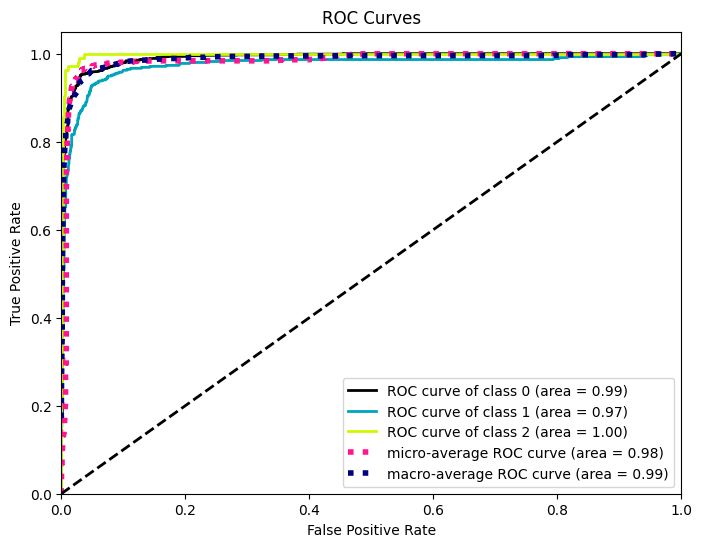

In [20]:
from sklearn.calibration import CalibratedClassifierCV
import scikitplot as skplt


# 2. Model Definition & Calibration
# Wrapping LinearSVC allows it to calculate probabilities
clf = CalibratedClassifierCV(LinearSVC(C=1.0, random_state=42, max_iter=2000))
clf.fit(X_train_sel, y_train_resampled)

# 3. Predictions
y_pred = clf.predict(X_test_sel)
y_score = clf.predict_proba(X_test_sel)

# 4. Text Evaluation (Contains Accuracy, F1, Precision, and Recall)
print("Classification Report:\n", classification_report(y_test, y_pred))

# 5. Visual Evaluation
skplt.metrics.plot_roc(y_test, y_score, figsize=(8, 6), title="ROC Curves")
plt.show()

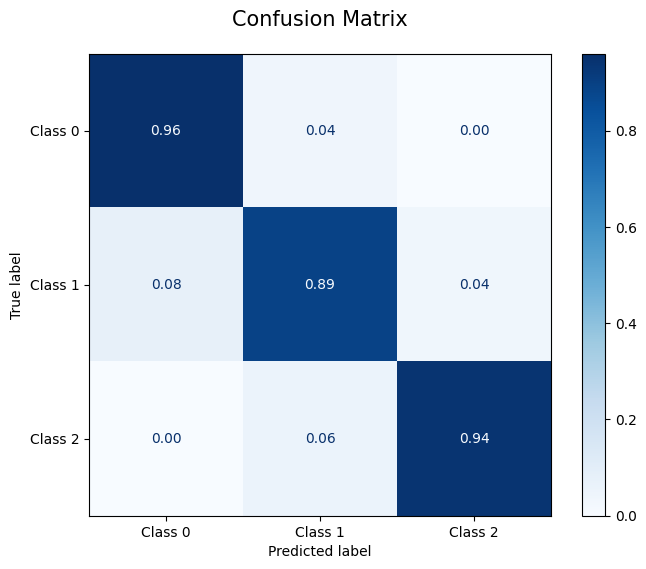

In [21]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

In [22]:
clf = LinearSVC(C=100.0, random_state=42)
clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.9475965327029157
F1-score [0.97170533 0.85744909 0.9       ]
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1980
           1       0.83      0.88      0.86       453
           2       0.86      0.94      0.90       105

    accuracy                           0.95      2538
   macro avg       0.89      0.93      0.91      2538
weighted avg       0.95      0.95      0.95      2538



In [23]:
clf = LinearSVC(C=0.001, random_state=42)
clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.9231678486997635
F1-score [0.97022143 0.77404403 0.72535211]
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1980
           1       0.81      0.74      0.77       453
           2       0.58      0.98      0.73       105

    accuracy                           0.92      2538
   macro avg       0.79      0.89      0.82      2538
weighted avg       0.93      0.92      0.93      2538



Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97      1980
           1       0.84      0.87      0.85       453
           2       0.82      0.96      0.89       105

    accuracy                           0.95      2538
   macro avg       0.88      0.93      0.90      2538
weighted avg       0.95      0.95      0.95      2538



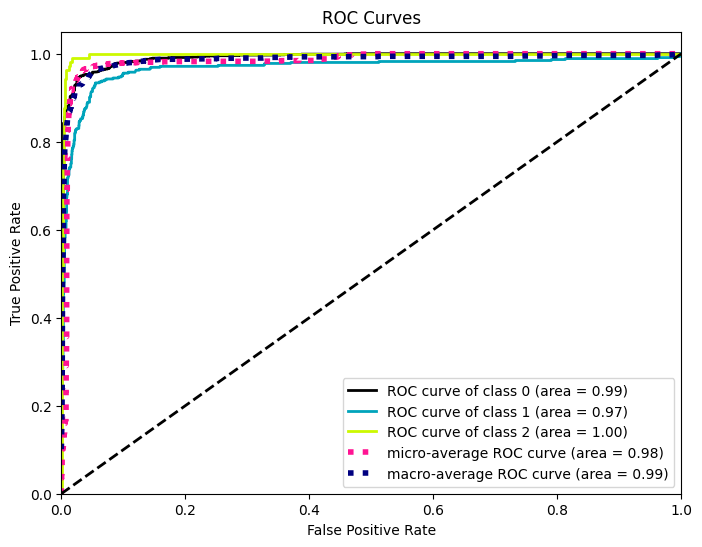

In [27]:
clf = CalibratedClassifierCV(LinearSVC(C=0.001, random_state=42))
clf.fit(X_train_sel, y_train_resampled)

# 3. Predictions
y_pred = clf.predict(X_test_sel)
y_score = clf.predict_proba(X_test_sel)

# 4. Text Evaluation (Contains Accuracy, F1, Precision, and Recall)
print("Classification Report:\n", classification_report(y_test, y_pred))

# 5. Visual Evaluation
skplt.metrics.plot_roc(y_test, y_score, figsize=(8, 6), title="ROC Curves")
plt.show()

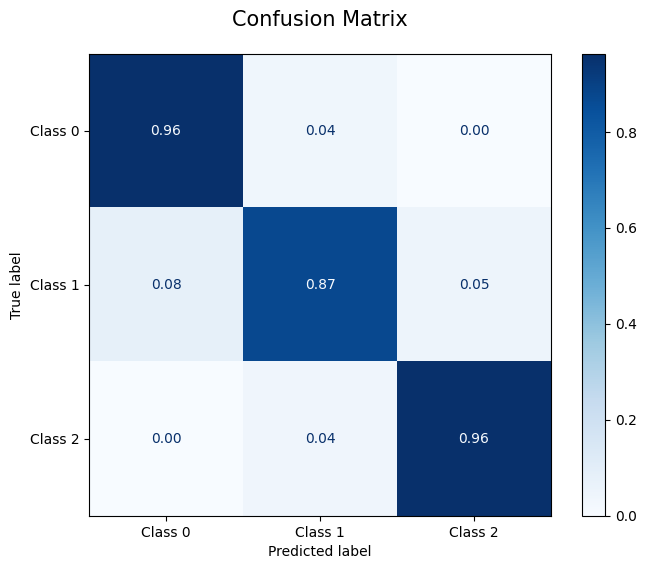

In [28]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

#### GridSearch

In [32]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [38]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
import xgboost as xgb

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('selector', SelectFromModel(
        xgb.XGBClassifier(
            random_state=42
        )
    )),
    ('svm', LinearSVC(
        loss='squared_hinge',     # scelta migliore
        dual=False,               # più efficiente se n_samples > n_features
        class_weight='balanced',  # fondamentale con sbilanciamento
        max_iter=5000,
        random_state=42
    ))
])

param_grid = {
    'svm__C': [0.01, 0.1, 1, 10, 100],
    'selector__threshold': ['mean', 'median']
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'selector__threshold': ['mean', 'median'], 'svm__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is

In [39]:
# Extract the Winning Parameters
print(f"Best Parameters found: {grid_search.best_params_}")

Best Parameters found: {'selector__threshold': 'median', 'svm__C': 10}


In [40]:
# Grab the "Winning" model
best_model = grid_search.best_estimator_

# Make predictions on the unseen test data
y_pred = best_model.predict(X_test)
# CHANGE: LinearSVC uses decision_function instead of predict_proba
y_prob = best_model.decision_function(X_test) 

# 3. The Evaluation Report
print("Final evaluation on test set")
print(f"Best internal CV Score: {grid_search.best_score_:.4f}")

print("\nDetailed Classification Report:")
# This shows Precision, Recall, and F1-Score 
print(classification_report(y_test, y_pred))

Final evaluation on test set
Best internal CV Score: 0.9950

Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1980
           1       0.99      0.98      0.99       453
           2       0.94      0.96      0.95       105

    accuracy                           1.00      2538
   macro avg       0.98      0.98      0.98      2538
weighted avg       1.00      1.00      1.00      2538



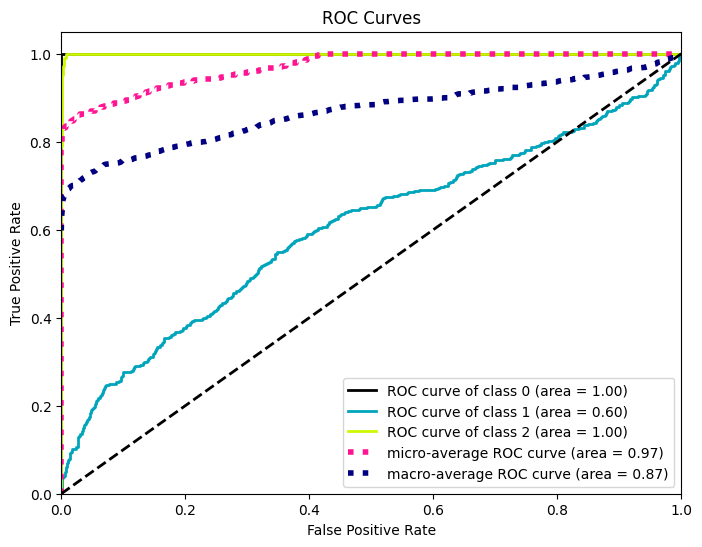

In [41]:
import scikitplot as skplt 

# 1. Get predictions from the BEST model found by GridSearch
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_score = best_model.decision_function(X_test)

# ROC curve 
# Works for both 2 and 4 classes
skplt.metrics.plot_roc(y_test, y_score, figsize=(8, 6), title="ROC Curves")
plt.show()


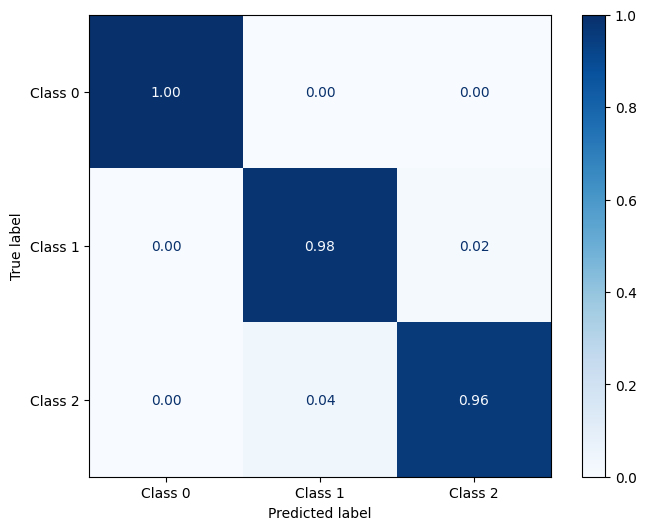

In [42]:
# Confusion Matrix
# Prepare labels dynamically based on current target
unique_classes = sorted(list(set(y_test)))
labels = [f"Class {i}" for i in unique_classes]

# Create the figure
fig, ax = plt.subplots(figsize=(8, 6))

# Use 'normalize=true' to see percentages per row
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=labels, 
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f'
)

#### Randomized search

In [45]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.svm import LinearSVC
from scipy.stats import loguniform
import xgboost as xgb

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('selector', SelectFromModel(
        xgb.XGBClassifier(
            n_estimators=100,
            random_state=42,
            eval_metric='logloss',
            use_label_encoder=False
        )
    )),
    ('linear_SVM', LinearSVC(
        loss='squared_hinge',
        dual=False,
        class_weight='balanced',
        max_iter=5000,
        random_state=42
    ))
])

param_dist = {
    'linear_SVM__C': loguniform(1e-3, 1e2),
    'selector__threshold': ['mean', 'median']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1_weighted',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'linear_SVM__C': <scipy.stats....0018EAF0DB650>, 'selector__threshold': ['mean', 'median']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` def

In [49]:
# Print the best parameters found
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best internal CV Score: {random_search.best_score_:.4f}")
print("\nDetailed Classification Report:")
# This shows Precision, Recall, and F1-Score 
print(classification_report(y_test, y_pred))

Best Parameters: {'linear_SVM__C': 14.528246637516036, 'selector__threshold': 'median'}
Best internal CV Score: 0.9957

Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1980
           1       0.99      0.98      0.99       453
           2       0.94      0.96      0.95       105

    accuracy                           1.00      2538
   macro avg       0.98      0.98      0.98      2538
weighted avg       1.00      1.00      1.00      2538



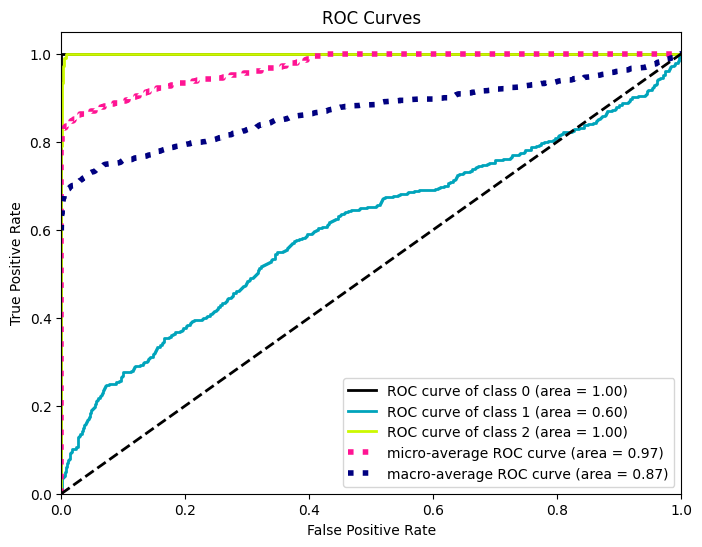

In [52]:
import scikitplot as skplt 

# 1. Get predictions from the BEST model found by GridSearch
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)
y_score = best_model.decision_function(X_test)

# ROC curve 
# Works for both 2 and 4 classes
skplt.metrics.plot_roc(y_test, y_score, figsize=(8, 6), title="ROC Curves")
plt.show()


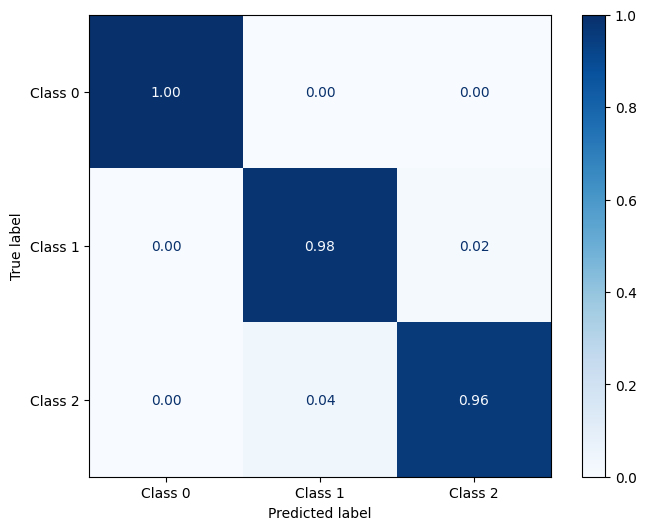

In [53]:
# Confusion Matrix
# Prepare labels dynamically based on current target
unique_classes = sorted(list(set(y_test)))
labels = [f"Class {i}" for i in unique_classes]

# Create the figure
fig, ax = plt.subplots(figsize=(8, 6))

# Use 'normalize=true' to see percentages per row
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=labels, 
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f'
)

**Consiglio PRO**

Fare questo confronto:

🔹 Caso 1 (originale)
4 classi
🔹 Caso 2 (merge)
3 classi

👉 e scrivi:

confronto F1
confronto ROC
spiegazione teorica

👉 questo è esattamente quello che vogliono vedere

#### New Target variable

In [54]:
from collections import Counter
from collections import defaultdict

**Basic_Demos-Enroll_Season**

In [55]:
df['sii']=df_original.loc[df.index, 'sii']
df.head()

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,...,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,Physical-BMI_New,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec,sii
0,0,5.0,0.0,3,51.00,0,46.000,50.8,26.0,73.9,...,50.55,71.8,0,3,16.877316,6.5,12.3225,2.006,448.0,2
1,2,9.0,0.0,1,62.55,0,48.000,46.0,22.0,75.0,...,46.00,64.0,2,0,14.035590,11.0,20.6250,2.010,334.0,0
2,2,10.0,1.0,0,71.00,0,56.500,75.6,25.4,65.0,...,38.00,54.0,2,2,16.648696,10.0,12.4500,2.009,453.0,0
3,3,9.0,0.0,0,71.00,2,56.000,81.6,26.0,60.0,...,31.00,45.0,3,0,18.292347,7.0,20.6250,2.010,577.0,1
4,1,18.0,1.0,2,65.00,1,55.003,77.0,26.0,68.0,...,41.60,61.4,1,1,17.894545,9.1,21.5525,1.040,460.0,1


In [56]:
df_SVM = df.copy()

In [57]:
df.drop(columns=['Basic_Demos-Enroll_Season'], inplace=True)

In [58]:
X = df.values
y = np.array(df_SVM['Basic_Demos-Enroll_Season'])

In [59]:
ctr = Counter(y)
ctr

Counter({1: 2447, 3: 2173, 2: 2002, 0: 1838})

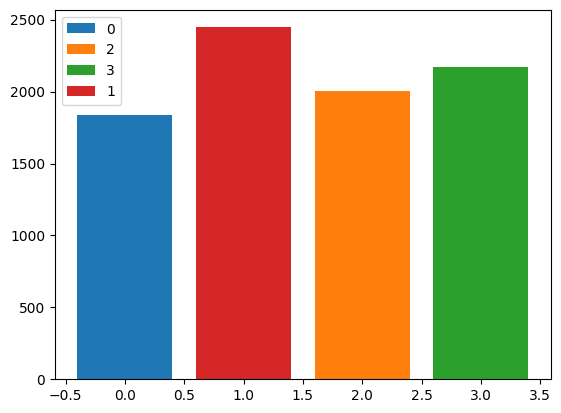

In [60]:
plt.bar(ctr.keys(), ctr.values(), label=ctr.keys(), color=['tab:blue', 'tab:orange', 'tab:green', 'tab:red'])
plt.legend()
plt.show()

In [61]:
def plot_pca(X_pca, y_train):
    classes = [0.0, 1.0, 2.0, 3.0]
    colors  = ['#2ca02c', '#d62728', '#1f77b4', '#ff7f0e']  # Verde, Rosso, Blu, Arancione

    for cls, color in zip(classes, colors):
        mask = y_train == cls
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, label=f'Class {int(cls)}',
                    edgecolor='k', alpha=0.7)

    plt.legend()
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('PCA — 2 componenti principali')
    plt.show()

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100)

In [63]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [64]:
# SMOTE 
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE : {X_train.shape[0]} samples")
print(f"After SMOTE : {X_train_resampled.shape[0]} samples")
print(f"Distribution of classes after SMOTE : {dict(zip(*np.unique(y_train_resampled, return_counts=True)))}")

Before SMOTE : 5922 samples
After SMOTE : 6852 samples
Distribution of classes after SMOTE : {0: 1713, 1: 1713, 2: 1713, 3: 1713}


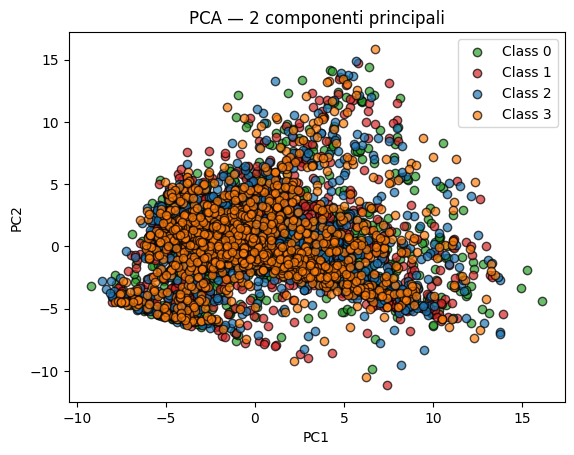

In [65]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_train_resampled)
plot_pca(X_pca, y_train_resampled)

In [66]:
# SelectFromModel with XGBoost

sel = SelectFromModel(xgb.XGBClassifier(random_state=42))
X_train_sel = sel.fit_transform(X_train_resampled, y_train_resampled)
X_test_sel = sel.transform(X_test)
X_train_sel.shape

(6852, 10)

In [67]:
clf = LinearSVC(C=1.0, random_state=42)

clf.fit(X_train_sel, y_train_resampled)
y_pred = clf.predict(X_test_sel)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-score (par classe) : {f1_score(y_test, y_pred, average=None)}")
print("\nClassification Report complet :")  
print(classification_report(y_test, y_pred))

Accuracy : 0.6139
F1-score (par classe) : [0.62186015 0.48204159 0.55408389 0.72483221]

Classification Report complet :
              precision    recall  f1-score   support

           0       0.49      0.85      0.62       537
           1       0.79      0.35      0.48       734
           2       0.73      0.45      0.55       562
           3       0.64      0.84      0.72       705

    accuracy                           0.61      2538
   macro avg       0.66      0.62      0.60      2538
weighted avg       0.67      0.61      0.60      2538



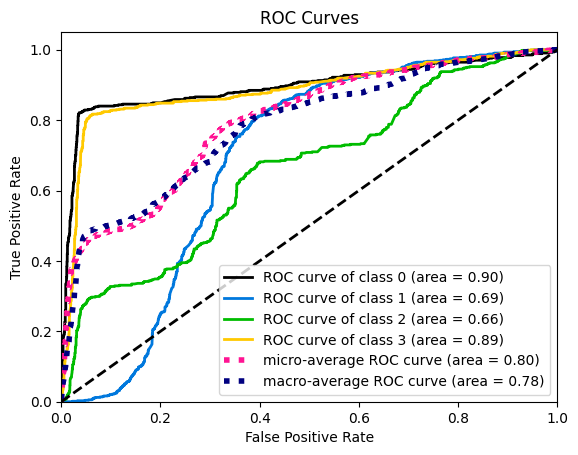

In [68]:
y_score = clf.decision_function(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

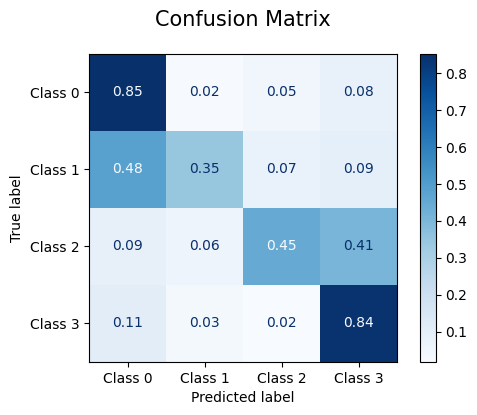

In [69]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(6, 4))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

**Basic_Demos-Sex**

In [70]:
df["Basic_Demos-Enroll_Season"] = df_SVM["Basic_Demos-Enroll_Season"]
df.head()

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,...,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,Physical-BMI_New,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec,sii,Basic_Demos-Enroll_Season
0,5.0,0.0,3,51.00,0,46.000,50.8,26.0,73.9,85.6,...,71.8,0,3,16.877316,6.5,12.3225,2.006,448.0,2,0
1,9.0,0.0,1,62.55,0,48.000,46.0,22.0,75.0,70.0,...,64.0,2,0,14.035590,11.0,20.6250,2.010,334.0,0,2
2,10.0,1.0,0,71.00,0,56.500,75.6,25.4,65.0,94.0,...,54.0,2,2,16.648696,10.0,12.4500,2.009,453.0,0,2
3,9.0,0.0,0,71.00,2,56.000,81.6,26.0,60.0,97.0,...,45.0,3,0,18.292347,7.0,20.6250,2.010,577.0,1,3
4,18.0,1.0,2,65.00,1,55.003,77.0,26.0,68.0,77.9,...,61.4,1,1,17.894545,9.1,21.5525,1.040,460.0,1,1


In [71]:
df_SVM = df.copy()

In [72]:
df.drop(columns=['Basic_Demos-Sex'], inplace=True)

In [73]:
X = df.values
y = np.array(df_SVM['Basic_Demos-Sex'])

In [74]:
ctr = Counter(y)
ctr

Counter({0.0: 5056, 1.0: 3404})

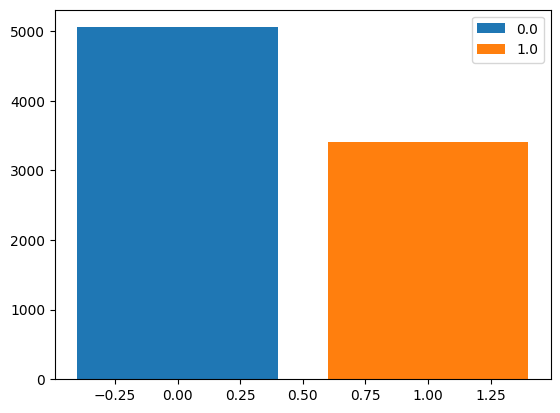

In [75]:
plt.bar(ctr.keys(), ctr.values(), label=ctr.keys(), color=['tab:blue', 'tab:orange'])
plt.legend()
plt.show()

In [76]:
def plot_pca(X_pca, y_train):
    classes = [0.0, 1.0]
    colors  = ['#2ca02c', '#d62728']  # Verde, Rosso

    for cls, color in zip(classes, colors):
        mask = y_train == cls
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, label=f'Class {int(cls)}',
                    edgecolor='k', alpha=0.7)

    plt.legend()
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('PCA — 2 componenti principali')
    plt.show()

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100)

In [78]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [79]:
# SMOTE 
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE : {X_train.shape[0]} samples")
print(f"After SMOTE : {X_train_resampled.shape[0]} samples")
print(f"Distribution of classes after SMOTE : {dict(zip(*np.unique(y_train_resampled, return_counts=True)))}")

Before SMOTE : 5922 samples
After SMOTE : 7080 samples
Distribution of classes after SMOTE : {0.0: 3540, 1.0: 3540}


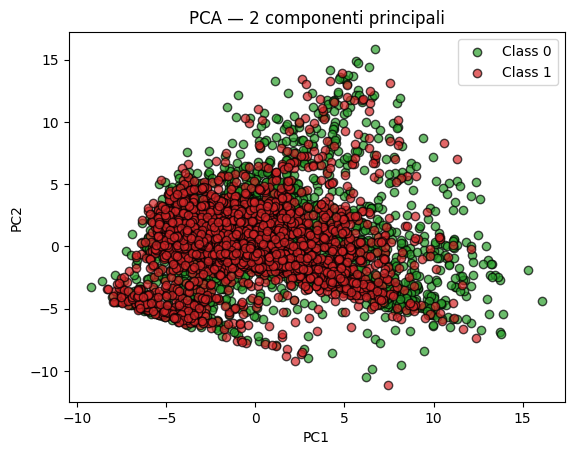

In [80]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_train_resampled)
plot_pca(X_pca, y_train_resampled)

In [81]:
# SelectFromModel with XGBoost
sel = SelectFromModel(xgb.XGBClassifier(random_state=42))
X_train_sel = sel.fit_transform(X_train_resampled, y_train_resampled)
X_test_sel = sel.transform(X_test)
X_train_sel.shape

(7080, 23)

In [82]:
clf = LinearSVC(C=1.0, random_state=42)

clf.fit(X_train_sel, y_train_resampled)
y_pred = clf.predict(X_test_sel)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-score (par classe) : {f1_score(y_test, y_pred, average=None)}")
print("\nClassification Report complet :")  
print(classification_report(y_test, y_pred))

Accuracy : 0.6793
F1-score (par classe) : [0.71052632 0.64045936]

Classification Report complet :
              precision    recall  f1-score   support

         0.0       0.77      0.66      0.71      1516
         1.0       0.58      0.71      0.64      1022

    accuracy                           0.68      2538
   macro avg       0.68      0.68      0.68      2538
weighted avg       0.70      0.68      0.68      2538



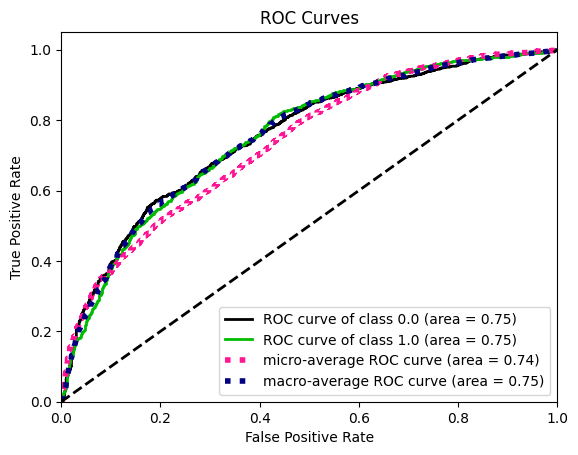

In [83]:
# 1. Get the 1D scores
y_score = clf.decision_function(X_test_sel)

# 2. Transform 1D scores into 2D "probabilities"
# We create a column for the negative class (0) and positive class (1)
y_score_2d = np.column_stack([1 - y_score, y_score])

# 3. Plot using the 2D array
plot_roc(y_test, y_score_2d)
plt.show()

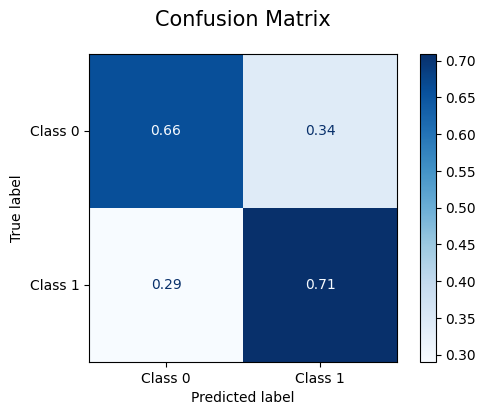

In [84]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(6, 4))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

### Nonlinear SVM

In [88]:
df_original = pd.read_csv("cmi_internet_WT_outlier_New_features.csv")
df = df_original.copy()

In [89]:
def encoder_labels_categoriques(df):
    """
    Prend un DataFrame en entrée, convertit les variables catégoriques 
    en nombres entiers (0, 1, 2, 3...) dans la même colonne, et retourne le DataFrame.
    """
    # 1. Copier le dataset pour éviter de modifier l'original
    df_encode = df.copy()
    
    # 2. Identifier les colonnes contenant du texte
    colonnes_categoriques = df_encode.select_dtypes(include=['object', 'category']).columns.tolist()
    
    if not colonnes_categoriques:
        print("Aucune colonne catégorique trouvée.")
        return df_encode
    
    # 3. Remplacer le texte par des codes numériques
    for colonne in colonnes_categoriques:
        # Convertit en type catégorie, puis récupère les codes numériques
        df_encode[colonne] = df_encode[colonne].astype('category').cat.codes
        
    return df_encode

In [90]:
df = encoder_labels_categoriques(df)

In [91]:
df.drop(columns=["PCIAT-PCIAT_Total", "sii"], inplace=True)

In [92]:
df

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,...,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,Physical-BMI_New,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec
0,0,5.0,0.0,3,51.00,0,46.000,50.8,26.000,73.90,...,0,50.55,71.80,0,3,16.877316,6.5,12.3225,2.006,448.0
1,2,9.0,0.0,1,62.55,0,48.000,46.0,22.000,75.00,...,0,46.00,64.00,2,0,14.035590,11.0,20.6250,2.010,334.0
2,2,10.0,1.0,0,71.00,0,56.500,75.6,25.400,65.00,...,0,38.00,54.00,2,2,16.648696,10.0,12.4500,2.009,453.0
3,3,9.0,0.0,0,71.00,2,56.000,81.6,26.000,60.00,...,2,31.00,45.00,3,0,18.292347,7.0,20.6250,2.010,577.0
4,1,18.0,1.0,2,65.00,1,55.003,77.0,26.000,68.00,...,0,41.60,61.40,1,1,17.894545,9.1,21.5525,1.040,460.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,1,7.0,1.0,1,65.15,0,46.070,49.0,22.250,58.50,...,2,38.50,55.00,1,0,16.229868,7.0,18.0750,2.000,547.7
8456,3,10.0,1.0,1,69.50,3,56.130,47.8,28.500,66.00,...,3,40.50,56.95,3,0,10.665793,5.0,13.5750,2.000,451.5
8457,3,10.0,1.0,3,70.00,3,49.560,47.2,25.635,63.50,...,3,43.75,60.75,1,2,13.509359,9.5,21.0375,2.004,528.0
8458,0,15.0,1.0,1,55.50,1,63.790,99.5,31.100,67.70,...,3,39.80,56.15,0,1,17.189894,10.5,24.4700,2.000,478.0


In [93]:
X = df.values
y = np.array(df_original.loc[df.index, 'sii'])

In [94]:
X.shape

(8460, 83)

In [95]:
np.unique(y, return_counts=True)

(array([0, 1, 2, 3], dtype=int64),
 array([6484, 1644,  326,    6], dtype=int64))

**I merge class 2 and 3 into a single class (class 2)**

In [96]:
# I merge class 2 and 3 into a single class (class 2)
y = np.where(y == 3, 2, y)

### Data Partitioning

In [97]:
from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [98]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100)

In [99]:
from sklearn.svm import SVC

In [100]:
# SMOTE 
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE : {X_train.shape[0]} samples")
print(f"After SMOTE : {X_train_resampled.shape[0]} samples")
print(f"Distribution of classes after SMOTE : {dict(zip(*np.unique(y_train_resampled, return_counts=True)))}")

Before SMOTE : 5922 samples
After SMOTE : 13512 samples
Distribution of classes after SMOTE : {0: 4504, 1: 4504, 2: 4504}


In [101]:
# SelectFromModel with XGBoost
sel = SelectFromModel(xgb.XGBClassifier(random_state=42))
X_train_sel = sel.fit_transform(X_train_resampled, y_train_resampled)
X_test_sel = sel.transform(X_test)
X_train_sel.shape

(13512, 14)

In [102]:
clf = SVC(C=1.0, random_state=42)
clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.9495665878644602
F1-score [0.97197223 0.86938776 0.90821256]
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1980
           1       0.81      0.94      0.87       453
           2       0.92      0.90      0.91       105

    accuracy                           0.95      2538
   macro avg       0.91      0.93      0.92      2538
weighted avg       0.95      0.95      0.95      2538



Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1980
           1       0.81      0.94      0.87       453
           2       0.91      0.90      0.90       105

    accuracy                           0.95      2538
   macro avg       0.90      0.93      0.91      2538
weighted avg       0.95      0.95      0.95      2538



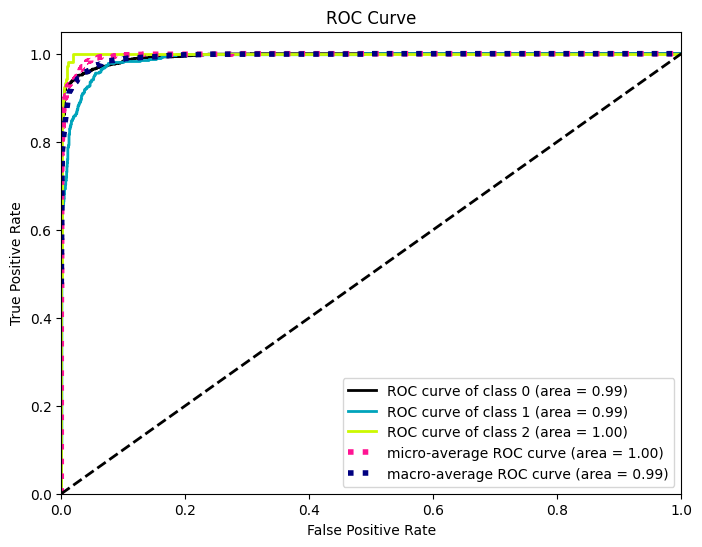

In [103]:
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
import scikitplot as skplt

# SVC does not provide calibrated probabilities by default
base_clf = SVC(C=1.0, random_state=42, max_iter=5000)

clf = CalibratedClassifierCV(base_clf, method="sigmoid", cv=5)
clf.fit(X_train_sel, y_train_resampled)

# 2. Predictions
y_pred = clf.predict(X_test_sel)
y_score = clf.predict_proba(X_test_sel)

# 3. Text Evaluation
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# 4. Visual Evaluation
skplt.metrics.plot_roc(
    y_test,
    y_score,
    figsize=(8, 6),
    title="ROC Curve"
)

plt.show()

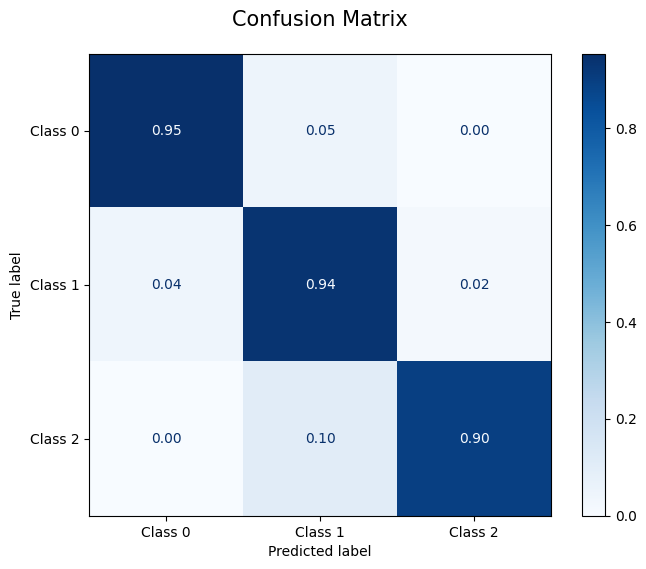

In [104]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

In [105]:
clf = SVC(C=100.0, random_state=42)
clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.9475965327029157
F1-score [0.97228579 0.85987261 0.87562189]
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      1980
           1       0.83      0.89      0.86       453
           2       0.92      0.84      0.88       105

    accuracy                           0.95      2538
   macro avg       0.91      0.90      0.90      2538
weighted avg       0.95      0.95      0.95      2538



In [106]:
clf = SVC(C=0.001, random_state=42)
clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.9263199369582348
F1-score [0.9646269  0.80552604 0.79389313]
              precision    recall  f1-score   support

           0       0.99      0.94      0.96      1980
           1       0.78      0.84      0.81       453
           2       0.66      0.99      0.79       105

    accuracy                           0.93      2538
   macro avg       0.81      0.92      0.85      2538
weighted avg       0.94      0.93      0.93      2538



#### GridSearch

In [107]:
from imblearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('selector', SelectFromModel(xgb.XGBClassifier(random_state=42))),
    ('svm', SVC(random_state=42))
])

param_grid = {
    'svm__C': [0.01, 0.1, 1, 10, 100],
    'svm__gamma': [1e-3, 1e-2, 1e-1],
    'svm__kernel': ['rbf']
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svm__C': [0.01, 0.1, ...], 'svm__gamma': [0.001, 0.01, ...], 'svm__kernel': ['rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2

In [108]:
# Extract the Winning Parameters
print(f"Best Parameters found: {grid_search.best_params_}")

Best Parameters found: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}


In [109]:
# Grab the "Winning" model
best_model = grid_search.best_estimator_

# Make predictions on the unseen test data
y_pred = best_model.predict(X_test)
# CHANGE: LinearSVC uses decision_function instead of predict_proba
y_prob = best_model.decision_function(X_test) 

# 3. The Evaluation Report
print("Final evaluation on test set")
print(f"Best internal CV Score: {grid_search.best_score_:.4f}")

print("\nDetailed Classification Report:")
# This shows Precision, Recall, and F1-Score 
print(classification_report(y_test, y_pred))

Final evaluation on test set
Best internal CV Score: 0.9465

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1980
           1       0.79      0.94      0.86       453
           2       0.92      0.84      0.88       105

    accuracy                           0.94      2538
   macro avg       0.90      0.91      0.90      2538
weighted avg       0.95      0.94      0.95      2538



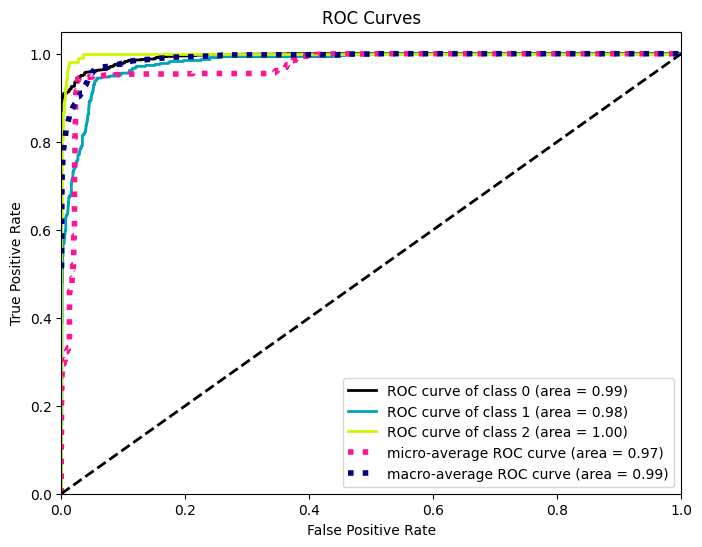

In [110]:
import scikitplot as skplt 

# 1. Get predictions from the BEST model found by GridSearch
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_score = best_model.decision_function(X_test)

# ROC curve 
# Works for both 2 and 4 classes
skplt.metrics.plot_roc(y_test, y_score, figsize=(8, 6), title="ROC Curves")
plt.show()


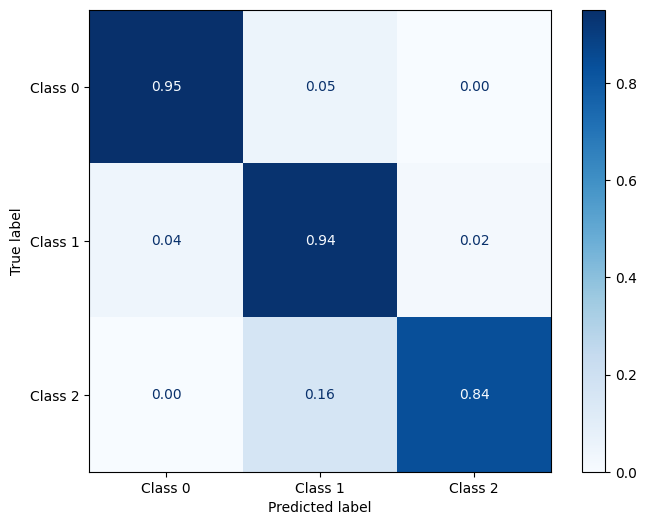

In [111]:
# Confusion Matrix
# Prepare labels dynamically based on current target
unique_classes = sorted(list(set(y_test)))
labels = [f"Class {i}" for i in unique_classes]

# Create the figure
fig, ax = plt.subplots(figsize=(8, 6))

# Use 'normalize=true' to see percentages per row
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=labels, 
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f'
)

#### Randomized search

In [116]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.svm import SVC
from scipy.stats import loguniform
import xgboost as xgb

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('selector', SelectFromModel(
        xgb.XGBClassifier(
            n_estimators=100,
            random_state=42,
            eval_metric='logloss',
            use_label_encoder=False
        )
    )),
    ('svm', SVC(
        class_weight='balanced',
        probability=True  # utile per ROC
    ))
])

param_dist = {
    'svm__C': loguniform(1e-3, 1e2),
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': ['scale', 'auto']  # usato solo per rbf
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1_weighted',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ility=True))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'svm__C': <scipy.stats....0018EA072A900>, 'svm__gamma': ['scale', 'auto'], 'svm__kernel': ['linear', 'rbf']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:

In [ ]:
# Print the best parameters found
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best internal CV Score: {random_search.best_score_:.4f}")

Best Parameters: {'svm__C': 1.1462107403425035, 'svm__gamma': 'auto', 'svm__kernel': 'rbf'}
Best internal CV Score: 0.9479



Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1980
           1       0.80      0.93      0.86       453
           2       0.89      0.86      0.87       105

    accuracy                           0.95      2538
   macro avg       0.89      0.91      0.90      2538
weighted avg       0.95      0.95      0.95      2538



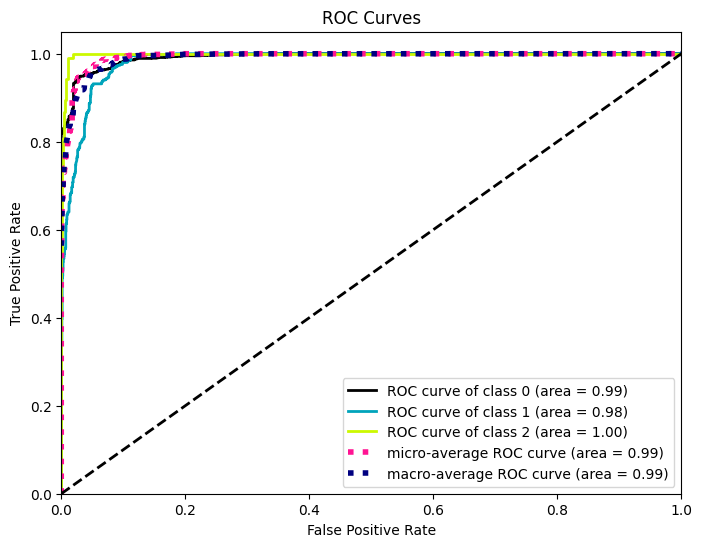

In [118]:
import scikitplot as skplt 

# 1. Get predictions from the BEST model found by GridSearch
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)
y_score = best_model.decision_function(X_test)

print("\nDetailed Classification Report:")
# This shows Precision, Recall, and F1-Score 
print(classification_report(y_test, y_pred))

# ROC curve 
# Works for both 2 and 4 classes
skplt.metrics.plot_roc(y_test, y_score, figsize=(8, 6), title="ROC Curves")
plt.show()


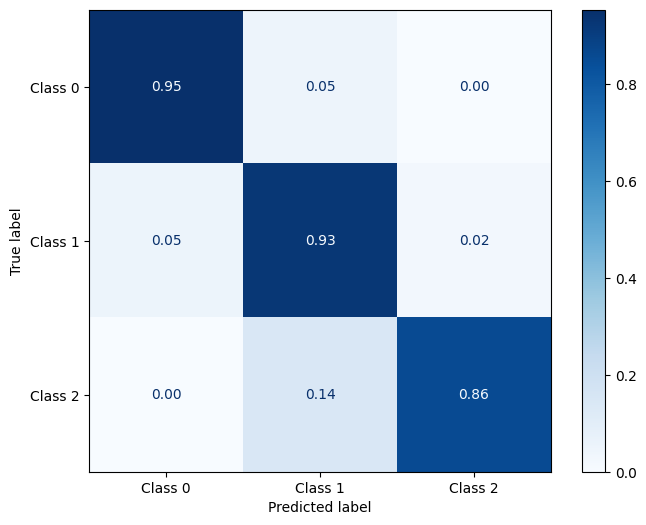

In [119]:
# Confusion Matrix
# Prepare labels dynamically based on current target
unique_classes = sorted(list(set(y_test)))
labels = [f"Class {i}" for i in unique_classes]

# Create the figure
fig, ax = plt.subplots(figsize=(8, 6))

# Use 'normalize=true' to see percentages per row
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=labels, 
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f'
)